1. Загрузка и базовая информация
Исходная размерность: 1001 строк, 214 столбцов
Целевые переменные: IC50, mM | CC50, mM | SI
Признаки-дескрипторы: 211 шт.
Проверка формулы SI = CC50 / IC50: ВЕРНО

2. Целостность данных
Строк с пропусками: 3 (0.3%)
Решение: <5% пропусков -> удаляем строки.
Дубликатов нет.
Размер после очистки: 998 строк × 214 столбцов

3. Статистика и выбросы
  IC50, mM: асимметрия = 3.71, выбросов = 145 (14.5%)
  CC50, mM: асимметрия = 1.99, выбросов = 39 (3.9%)
  SI: асимметрия = 17.96, выбросов = 124 (12.4%)
Решение: Выбросы сохранены (могут быть активными лидами). Применено log1p для стабилизации дисперсии.

4. Генерация графиков


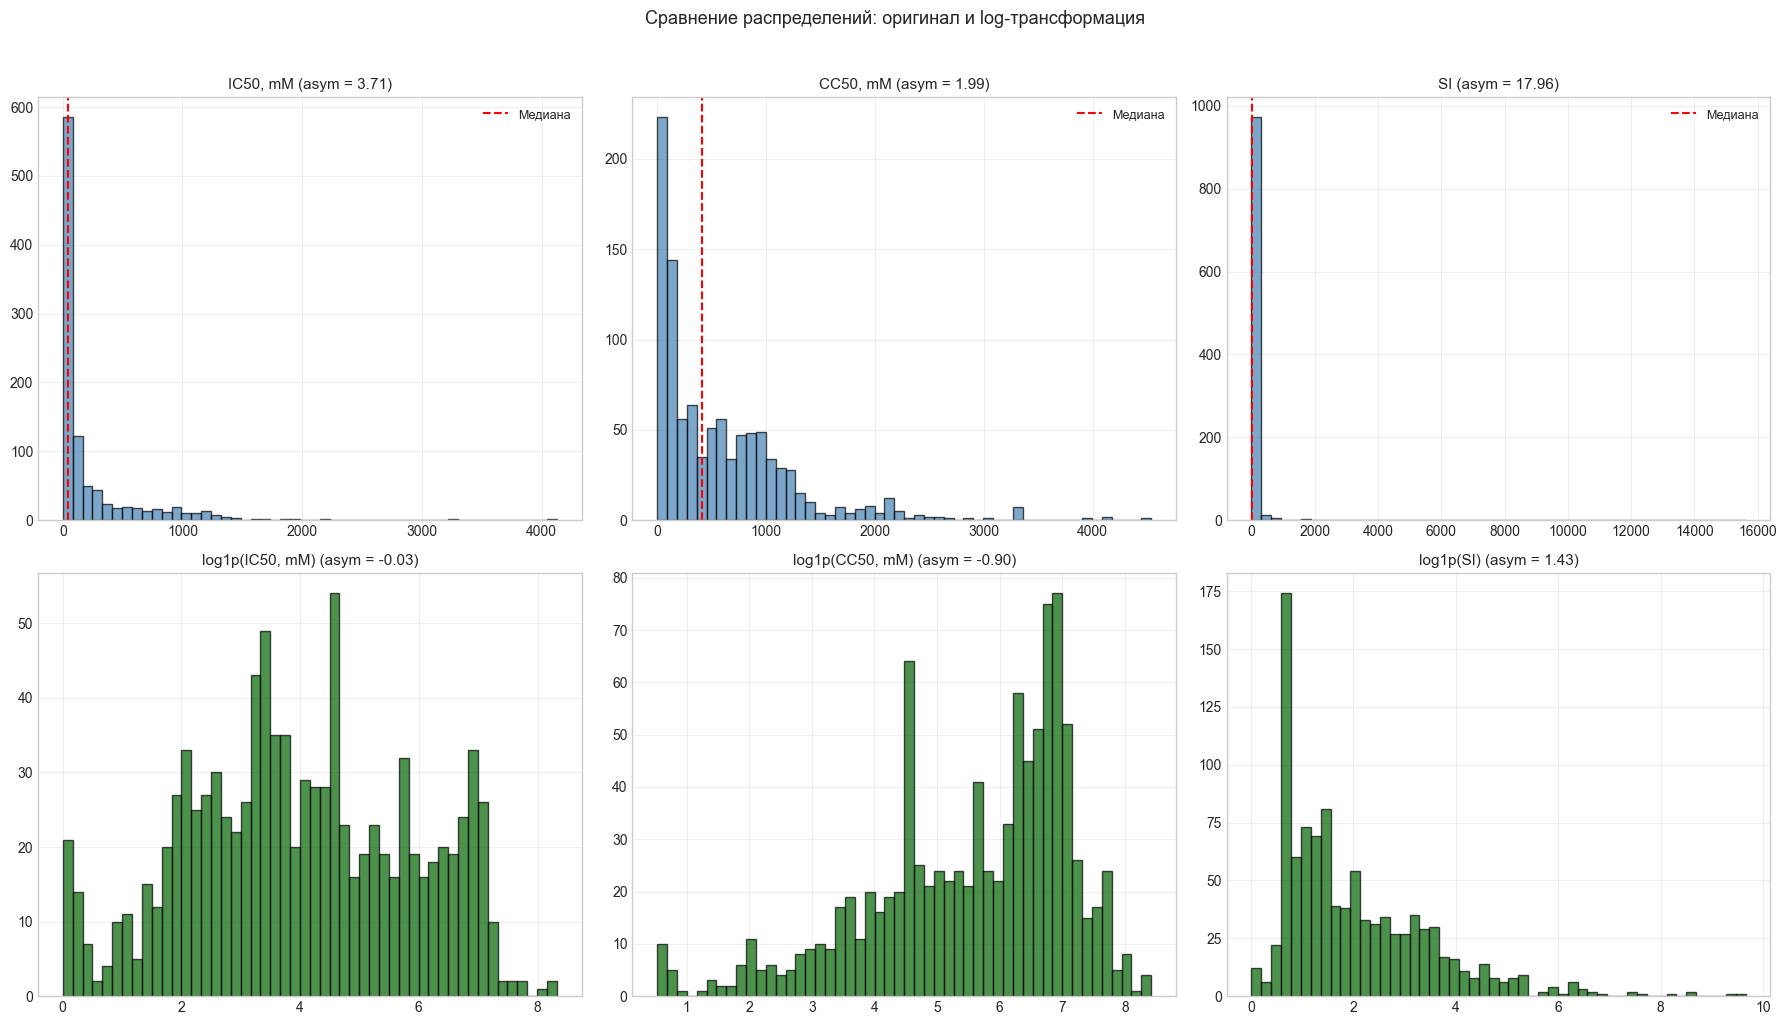

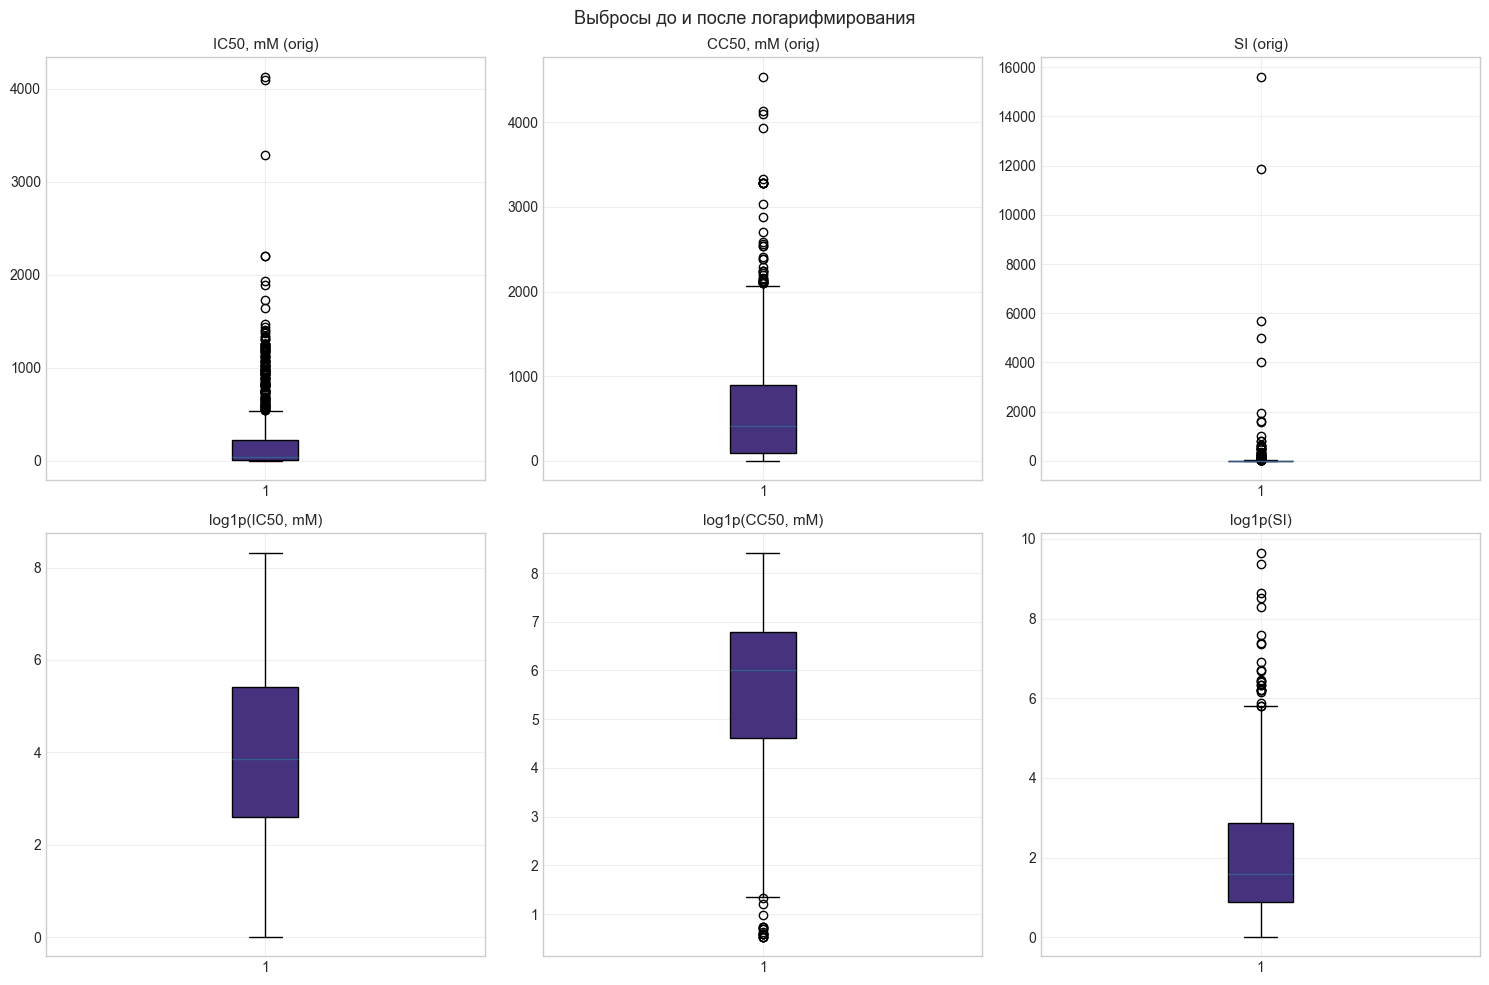

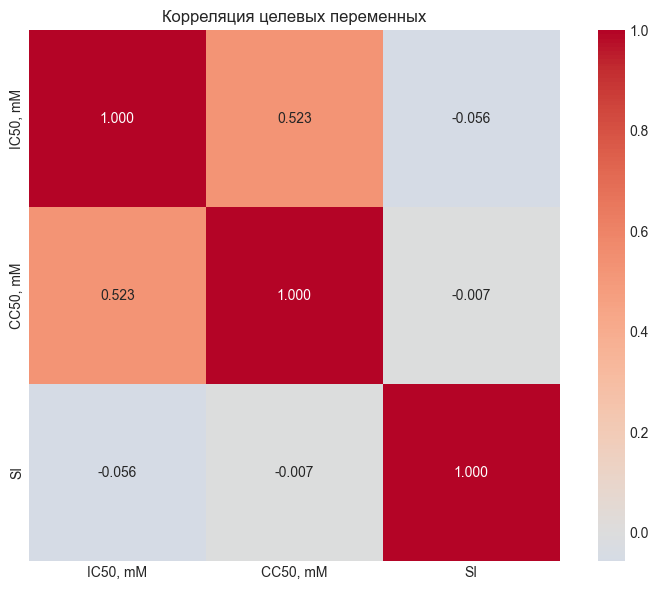

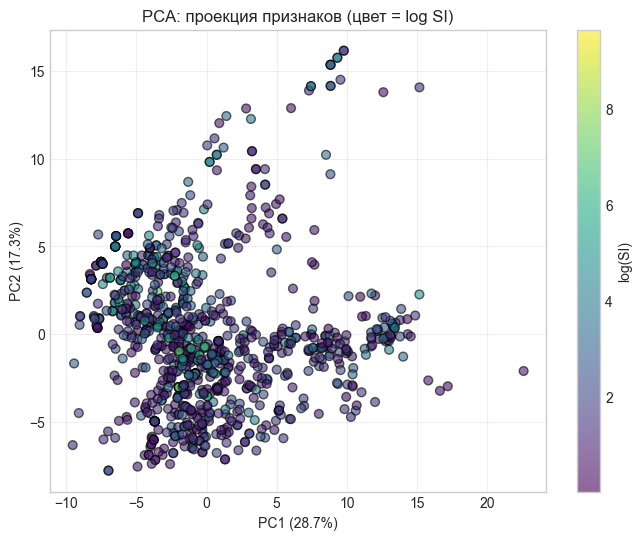

  PCA: PC1 = 28.7%, PC2 = 17.3%
  Графики сгенерированы для визуального анализа.

5. Анализ признаков
  Константные (удалены): 18
  Низкодисперсные (оставлены): 0
  Пар с корреляцией > 0.95: 57
  Решение: Не удаляем вручную. Регуляризация и деревья справятся с мультиколлинеарностью без потери информации.

6. Подготовка финального датасета
  Удалено служебных/константных столбцов: 23
  Итоговая размерность: 998 × 194
  Признаки для моделей: 188
  Целевые (ориг + log): 3 + 3

Данные сохранены в 'Данные_после_EDA.xlsx'
EDA завершено.


In [1]:
# Курсовая работа. Классическое машинное обучение
# Этап 1. Загрузка и анализ данных (EDA)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Настройка визуализации
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

# 1. Загрузка данных
file_path = 'Данные_для_курсовои_Классическое_МО.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1', header=0)

print("1. Загрузка и базовая информация")
print(f"Исходная размерность: {df.shape[0]} строк, {df.shape[1]} столбцов")
print(f"Целевые переменные: IC50, mM | CC50, mM | SI")
print(f"Признаки-дескрипторы: {df.shape[1] - 3} шт.")

# Проверка формулы SI
df_check = df.copy()
df_check['SI_calc'] = df_check['CC50, mM'] / df_check['IC50, mM']
si_valid = np.allclose(df_check['SI'], df_check['SI_calc'], rtol=1e-5)
print(f"Проверка формулы SI = CC50 / IC50: {'ВЕРНО' if si_valid else 'НЕ ВЕРНО'}")

# 2. Пропуски и дубликаты
print("\n2. Целостность данных")
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_cols = missing_pct[missing_pct > 0].index.tolist()

if len(missing_cols) > 0:
    rows_missing = df[df.isnull().any(axis=1)]
    pct_missing = (len(rows_missing) / len(df)) * 100
    print(f"Строк с пропусками: {len(rows_missing)} ({pct_missing:.1f}%)")
    
    if pct_missing < 5.0:
        df_clean = df.dropna().copy()
        print("Решение: <5% пропусков -> удаляем строки.")
    else:
        df_clean = df.copy()
        for col in missing_cols:
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())
        print("Решение: >=5% пропусков -> заполняем медианой.")
else:
    df_clean = df.copy()
    print("Пропусков не обнаружено.")

duplicates = df_clean.duplicated().sum()
if duplicates > 0:
    df_clean = df_clean.drop_duplicates().reset_index(drop=True)
    print(f"Удалено дубликатов: {duplicates}")
else:
    print("Дубликатов нет.")

print(f"Размер после очистки: {df_clean.shape[0]} строк × {df_clean.shape[1]} столбцов")

# 3. Статистика и выбросы (IQR)
print("\n3. Статистика и выбросы")
target_cols = ['IC50, mM', 'CC50, mM', 'SI']

def detect_outliers(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return ((series < Q1 - 1.5*IQR) | (series > Q3 + 1.5*IQR)).sum()

for col in target_cols:
    n_out = detect_outliers(df_clean[col])
    print(f"  {col}: асимметрия = {skew(df_clean[col]):.2f}, выбросов = {n_out} ({(n_out/len(df_clean))*100:.1f}%)")

# Логарифмическое преобразование
for col in target_cols:
    df_clean[f'log_{col}'] = np.log1p(df_clean[col])

print("Решение: Выбросы сохранены (могут быть активными лидами). Применено log1p для стабилизации дисперсии.")

# 4. Визуализация (только отображение, без сохранения)
print("\n4. Генерация графиков")

# 4.1 Гистограммы: оригинал vs log
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, col in enumerate(target_cols):
    axes[0, i].hist(df_clean[col].dropna(), bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[0, i].axvline(df_clean[col].median(), color='red', ls='--', label='Медиана')
    axes[0, i].set_title(f'{col} (asym = {skew(df_clean[col]):.2f})', fontsize=11)
    axes[0, i].legend(fontsize=9)
    axes[0, i].grid(True, alpha=0.3)
    
    axes[1, i].hist(np.log1p(df_clean[col].dropna()), bins=50, edgecolor='black', alpha=0.7, color='darkgreen')
    axes[1, i].set_title(f'log1p({col}) (asym = {skew(np.log1p(df_clean[col])):.2f})', fontsize=11)
    axes[1, i].grid(True, alpha=0.3)

plt.suptitle('Сравнение распределений: оригинал и log-трансформация', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# 4.2 Boxplot до/после
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, col in enumerate(target_cols):
    axes[0, i].boxplot(df_clean[col], vert=True, patch_artist=True)
    axes[0, i].set_title(f'{col} (orig)', fontsize=11)
    axes[0, i].grid(True, alpha=0.3)
    
    axes[1, i].boxplot(np.log1p(df_clean[col]), vert=True, patch_artist=True)
    axes[1, i].set_title(f'log1p({col})', fontsize=11)
    axes[1, i].grid(True, alpha=0.3)

plt.suptitle('Выбросы до и после логарифмирования', fontsize=13)
plt.tight_layout()
plt.show()

# 4.3 Heatmap корреляции таргетов
plt.figure(figsize=(8, 6))
sns.heatmap(df_clean[target_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.3f', square=True)
plt.title('Корреляция целевых переменных', fontsize=12)
plt.tight_layout()
plt.show()

# 4.4 PCA
feature_cols_clean = [col for col in df_clean.columns if col not in target_cols and not col.startswith('log_')]
const_feat = [col for col in feature_cols_clean if df_clean[col].std() < 1e-6]
pca_feats = [col for col in feature_cols_clean if col not in const_feat][:100]

if len(pca_feats) > 2:
    X_sc = StandardScaler().fit_transform(df_clean[pca_feats].fillna(0))
    pca = PCA(n_components=2).fit(X_sc)
    res = pca.transform(X_sc)
    
    plt.figure(figsize=(8, 6))
    sc = plt.scatter(res[:, 0], res[:, 1], c=np.log1p(df_clean['SI']), cmap='viridis', alpha=0.6, edgecolors='k', s=40)
    plt.colorbar(sc, label='log(SI)')
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    plt.title('PCA: проекция признаков (цвет = log SI)')
    plt.grid(True, alpha=0.3)
    plt.show()
    print(f"  PCA: PC1 = {pca.explained_variance_ratio_[0]*100:.1f}%, PC2 = {pca.explained_variance_ratio_[1]*100:.1f}%")

print("  Графики сгенерированы для визуального анализа.")

# 5. Анализ признаков
print("\n5. Анализ признаков")
print(f"  Константные (удалены): {len(const_feat)}")
print(f"  Низкодисперсные (оставлены): {len([c for c in feature_cols_clean if c not in const_feat and df_clean[c].std() < 0.01 * abs(df_clean[c].mean())])}")

# Мультиколлинеарность
sample = feature_cols_clean[:50]
corr = df_clean[sample].corr().abs()
tri = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr = [(r, c, v) for c in tri.columns for r, v in tri[c].items() if v > 0.95]
print(f"  Пар с корреляцией > 0.95: {len(high_corr)}")
print("  Решение: Не удаляем вручную. Регуляризация и деревья справятся с мультиколлинеарностью без потери информации.")

# 6. Финальная сборка
print("\n6. Подготовка финального датасета")
df_final = df_clean.copy()

# Удаляем константные и технические индексы
drop_cols = const_feat + [c for c in df_final.columns if 'unnamed' in c.lower() or 'index' in c.lower()]
if drop_cols:
    df_final = df_final.drop(columns=drop_cols)
    print(f"  Удалено служебных/константных столбцов: {len(drop_cols)}")

final_feat = [c for c in df_final.columns if c not in target_cols and not c.startswith('log_')]
log_tgt = [f'log_{c}' for c in target_cols]

print(f"  Итоговая размерность: {df_final.shape[0]} × {df_final.shape[1]}")
print(f"  Признаки для моделей: {len(final_feat)}")
print(f"  Целевые (ориг + log): {len(target_cols)} + {len(log_tgt)}")

df_final.to_excel('Данные_после_EDA.xlsx', index=False)
print("\nДанные сохранены в 'Данные_после_EDA.xlsx'")
print("EDA завершено.")

### Анализ распределений целевых переменных
Исходные распределения `IC50`, `CC50` и `SI` демонстрируют выраженную положительную асимметрию (асимметрия = 3.71, 1.99 и 17.96 соответственно). Это типично для биохимических концентраций, где большинство соединений обладают умеренной активностью, а небольшое число "лидов" уходит в экстремальные значения.

Применение преобразования `log1p(x)` позволило:
1. **Снизить асимметрию** до значений, близких к нормальному распределению (`IC50`: -0.03, `CC50`: -0.90, `SI`: 1.43).
2. **Стабилизировать дисперсию** (устранить гетероскедастичность), что критично для регрессионных метрик (R², RMSE).
3. **Сохранить физический смысл**: в фармакокинетике зависимость "доза-эффект" часто носит мультипликативный характер, поэтому логарифмическая шкала лучше отражает биологическую реальность, чем линейная.

*Упрощение задачи:* После логарифмирования модели могут обучаться на более сбалансированных градиентах, что повышает стабильность подбора гиперпараметров и улучшает обобщающую способность на тестовой выборке.

### Анализ выбросов (метод IQR)
Метод межквартильного размаха выявил 14.5% выбросов для `IC50`, 3.9% для `CC50` и 12.4% для `SI`. 

**Решение:** Выбросы **не удалялись**. В контексте drug discovery экстремальные значения часто соответствуют высокоактивным или высокотоксичным соединениям, которые представляют наибольший интерес для скрининга. Их удаление привело бы к смещению модели в сторону "средних" молекул и потере предсказательной силы для потенциальных лекарственных кандидатов.

Вместо удаления применены:
- `log1p`-трансформация (сжатие хвостов распределения).
- `RobustScaler` при масштабировании (устойчив к медиане и IQR, а не к среднему и дисперсии).
- Деревья решений и бустинги (инвариантны к монотонным преобразованиям и устойчивы к выбросам за счёт разбиения пространства признаков).

### Корреляционный анализ целевых переменных
Heatmap корреляций показывает:
- Умеренную положительную связь между `IC50` и `CC50` (**r = 0.523**). Это указывает на то, что механизмы вирусного ингибирования и цитотоксичности частично пересекаются, но остаются достаточно независимыми.
- Слабую корреляцию `SI` с исходными переменными (`r ≈ -0.05`), что ожидаемо, так как `SI = CC50 / IC50` является производной величиной.

*Вывод для моделирования:* Подтверждена независимость задач. Совместное обучение возможно, но раздельное моделирование `IC50` и `CC50` с последующим расчётом `SI` позволит сохранить интерпретируемость и избежать накопления ошибок на этапе оптимизации.

###  PCA: визуализация признакового пространства
Метод главных компонент показывает, что первые две компоненты объясняют **46.0% дисперсии** (PC1 = 28.7%, PC2 = 17.3%). На scatter-plot (PC1 vs PC2, цвет = `log(SI)`) отсутствует линейная сепарабельность: точки разных классов селективности перемешаны, образуя сложную нелинейную структуру.

*Вывод:* 
1. Линейные модели (Ridge, Logistic Regression) будут заведомо ограничены в качестве, так как данные не линейно разделимы.
2. Необходимо использование **нелинейных ансамблей** (Random Forest, Gradient Boosting, XGBoost, LightGBM), способных аппроксимировать сложные границы решений.
3. Агрессивное снижение размерности через PCA нецелесообразно: более 50% информации теряется уже на 2-й компоненте, а молекулярные дескрипторы часто содержат полезные локальные взаимодействия.

### Мультиколлинеарность и подготовка к моделированию
Анализ выявил **57 пар признаков** с корреляцией > 0.95. Ручное удаление не проводилось по следующим причинам:
1. **Деревья и бустинги** автоматически выбирают наиболее информативный признак из коррелирующей группы при разбиении узла, игнорируя дублирующие.
2. Удаление может привести к потере тонких нелинейных взаимодействий, важных для QSAR-моделей.
3. Регуляризация в градиентном бустинге и ограничение глубины деревьев эффективно контролируют переобучение даже при высокой корреляции.

**Итог EDA и упрощение задачи:**
- Выборка сбалансирована по размеру (998 строк, 188 признаков), что достаточно для классического ML при использовании 5-Fold CV.
- Логарифмирование + RobustScaler решили проблему тяжёлых хвостов и выбросов.
- Нелинейная структура данных и отсутствие линейной сепарабельности чётко указывают на приоритет ансамблевых методов над линейными.
- Данные сохранены в `'Данные_после_EDA.xlsx'` и готовы к подаче на вход моделей.